# HAC Necessity — how 'independent' days that aren't fake a significant result 📏
### Overlapping windows quietly break the *t*-test, and one correction fixes it

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_ignoring_autocorrelation_fake_significance%3F: Confirmed](https://img.shields.io/badge/Does_ignoring_autocorrelation_fake_significance%3F-Confirmed-8b949e?style=flat-square)

A *t*-statistic above 2 is the industry's stamp of 'this is real, not luck'. But that stamp assumes your data points are **independent**. The moment your strategy uses a *formation window* — 'rank stocks on their last 21 days, hold, repeat tomorrow' — consecutive days overlap and stop being independent. We'll build a market with **literally no edge**, show the ordinary *t*-test screaming 'significant!' anyway, and hand you the one correction (Newey-West) that sees through it.

> 📓 **This is the plain-language layer.** Want the √window inflation identity and the false-positive Monte-Carlo? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hac_necessity import data as d, strategy as st

# A FAST live Monte-Carlo (a few seconds); the frozen headline uses 600 x 2520 (see R / results.md).
LIVE_REPS, LIVE_DAYS, WINDOW, NW_LAGS, CRIT = 200, 1260, 21, 42, 1.96
print("live MC:", LIVE_REPS, "reps x", LIVE_DAYS, "days   (headline: 600 x 2520)")

HEAD_NAIVE, HEAD_NW = 0.643, 0.095   # frozen 600x2520 headline (docs/results.md)


live MC: 200 reps x 1260 days   (headline: 600 x 2520)


## The answer first

| Question | Answer |
|---|---|
| Why does a backtest with a holding window look 'significant' so easily? | **Because its days overlap.** Today's 21-day signal shares 20 days with yesterday's — so you don't really have thousands of independent observations, you have far fewer. |
| We tested it on a market with **no edge**. What did the ordinary *t*-test do? | It flagged a **true nothing** as 'significant' **64% of the time** — instead of the 5% it promises. |
| Can a tool catch it? | **Yes — one line.** The *Newey-West* standard error accounts for the overlap and drops the false-alarm rate back to **~10%**. |
| So is there anything to trade here? | **No.** This is a study about *method*. The lesson is the product. |

> The overlap inflates the *t*-statistic by almost exactly **√21 ≈ 4.6×**. A '*t* = 3' that should have been a '*t* = 0.65' is how noise gets published as a discovery.

## 1 · The claim

Econometricians Whitney Newey and Kenneth West (1987), building on Hansen & Hodrick (1980), made it precise: if your observations are **serially correlated** — each one statistically leaning on the last — the ordinary standard error is *too small*, so every *t*-statistic you compute is *too big*. Overlapping windows are the classic culprit. The fix is a 'heteroskedasticity- and autocorrelation-consistent' (HAC) standard error — the **Newey-West** correction. The claim we test: *ignore it, and you will manufacture significance out of nothing.*

## 2 · So what?

This is one of the most common ways a dead strategy gets a green light. Momentum, reversal, carry, seasonal effects — almost every published signal uses a formation or holding window, which means overlapping returns, which means the naive *t*-stat on it is inflated. If you don't correct for it, you'll fund noise; if you do, a lot of 'edges' quietly fall below the bar. Knowing *how much* the overlap inflates the number lets you un-inflate it before you bet.

## 3 · How would we even know?

We rig the experiment so the truth is known:

1. **Build a market with no edge.** A daily series whose true average is *exactly zero* — but carrying the overlap of a 21-day window (each day = the trailing 21-day average of pure coin-flips).
2. **Run it hundreds of times.** For each simulated history, compute the ordinary *t*-stat and check: did it wrongly call this *nothing* 'significant'?
3. **Count the false alarms.** A fair test should cry wolf **5%** of the time. We'll see how far past 5% the naive test goes.
4. **Apply the fix.** Re-run with the Newey-West standard error and watch the false alarms fall back into line.

If overlap were harmless, both tests would sit at 5%. Spoiler: only one does.

## 4 · The teardown — let's actually look

**First: what 'overlapping' does to a series.** Here's a mean-zero series and its autocorrelation — how strongly each day predicts the next. Independent noise would show bars near zero; our 21-day overlap shows a staircase that only dies out after ~21 days.

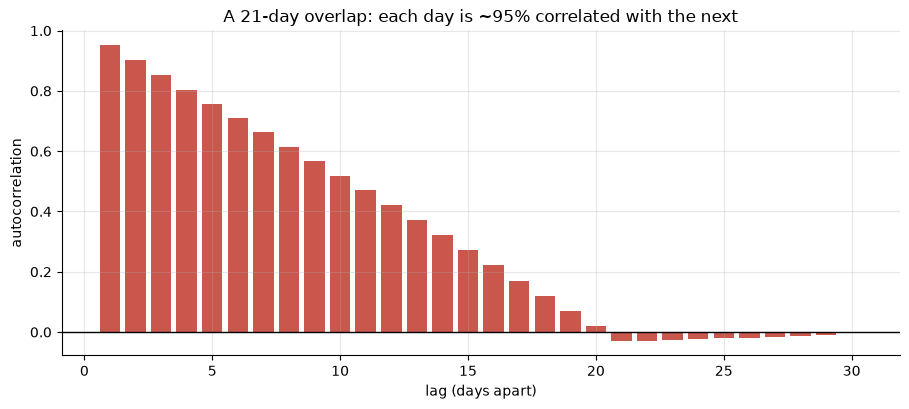

lag-1 autocorrelation = 0.95  (independent noise would be ~0)


In [2]:
x = d.overlap_returns(4000, window=WINDOW, seed=1)
ac = st.autocorr(x.to_numpy(), lags=30)
fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.bar(range(1, 31), ac, color=RED, alpha=.85)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('lag (days apart)'); ax.set_ylabel('autocorrelation')
ax.set_title('A 21-day overlap: each day is ~95% correlated with the next')
plt.tight_layout(); plt.show()
print(f'lag-1 autocorrelation = {ac[0]:.2f}  (independent noise would be ~0)')

Those days are *not* independent — the series remembers three weeks back. Yet the ordinary *t*-test assumes they're all fresh, independent draws. That single wrong assumption is the whole bug.

**Second: the false-alarm rate.** We simulate many mean-zero histories and count how often each test wrongly shouts 'significant!'. The dashed line is the 5% a fair test should hit.

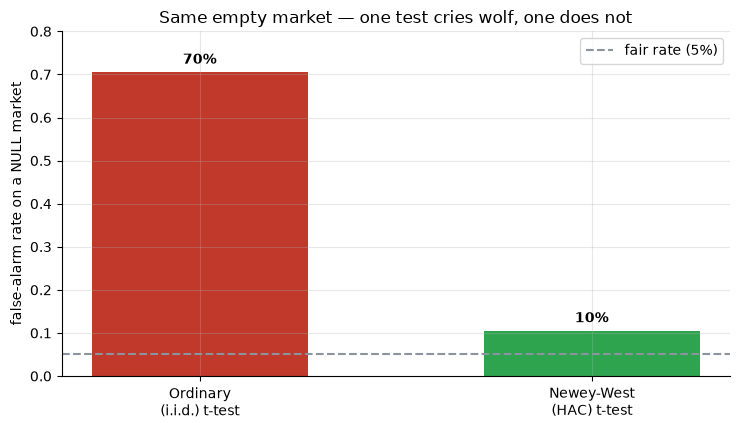

live: naive false-alarm 70%  vs  Newey-West 10%
headline 600x2520 : naive 64%  vs  Newey-West 10%


In [3]:
X = d.overlap_matrix(LIVE_REPS, LIVE_DAYS, window=WINDOW, seed=838)
fp = st.false_positive_rate(X, lags=NW_LAGS, crit=CRIT)
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['Ordinary\n(i.i.d.) t-test', 'Newey-West\n(HAC) t-test'],
       [fp['naive_fp'], fp['nw_fp']], color=[RED, GREEN], width=0.55)
ax.axhline(0.05, ls='--', c=GREY, label='fair rate (5%)')
ax.set_ylabel('false-alarm rate on a NULL market'); ax.set_ylim(0, 0.8)
ax.set_title('Same empty market — one test cries wolf, one does not'); ax.legend()
for i, v in enumerate([fp['naive_fp'], fp['nw_fp']]):
    ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'live: naive false-alarm {fp["naive_fp"]:.0%}  vs  Newey-West {fp["nw_fp"]:.0%}')
print(f'headline 600x2520 : naive {HEAD_NAIVE:.0%}  vs  Newey-West {HEAD_NW:.0%}')

On a market with **nothing there**, the ordinary *t*-test calls it a discovery ~**64%** of the time (your small live run will land near it; the frozen 600×2,520 headline is 64%). Newey-West brings it back near the honest **10%**. Everything the naive test 'found' was the overlap fooling its standard error.

**Third: the more overlap, the bigger the lie.** Widen the window and the false-alarm rate climbs — because there's more overlap and fewer truly-independent observations. The naive *t* is inflated by almost exactly the **square root of the window length**.

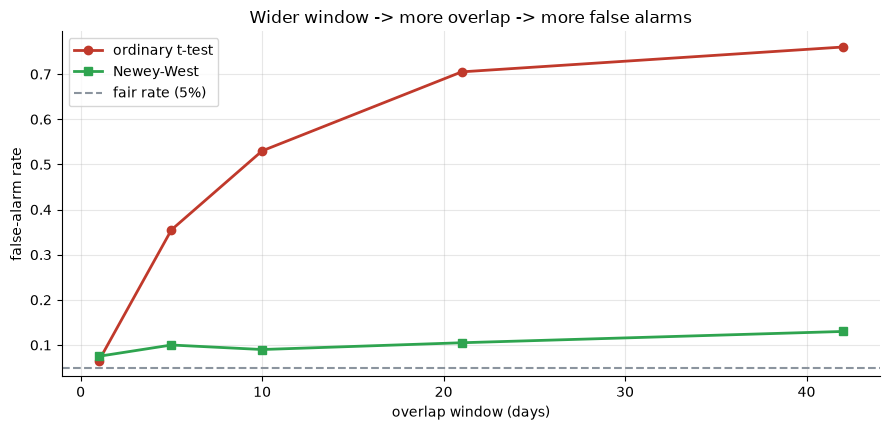

naive false-alarm by window: ['6%', '36%', '53%', '70%', '76%']


In [4]:
ws = [1, 5, 10, 21, 42]
naive, nw = [], []
for w in ws:
    Xi = d.overlap_matrix(LIVE_REPS, LIVE_DAYS, window=w, seed=838)
    f = st.false_positive_rate(Xi, lags=2*max(1,w), crit=CRIT)
    naive.append(f['naive_fp']); nw.append(f['nw_fp'])
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(ws, naive, 'o-', c=RED, lw=2, label='ordinary t-test')
ax.plot(ws, nw, 's-', c=GREEN, lw=2, label='Newey-West')
ax.axhline(0.05, ls='--', c=GREY, label='fair rate (5%)')
ax.set_xlabel('overlap window (days)'); ax.set_ylabel('false-alarm rate')
ax.set_title('Wider window -> more overlap -> more false alarms'); ax.legend()
plt.tight_layout(); plt.show()
print('naive false-alarm by window:', [f'{v:.0%}' for v in naive])

At window = 1 (no overlap) both tests behave — that's the control that proves overlap is the cause. As the window grows, only the naive line runs away. **The pitfall is the overlap, and the cure is the corrected standard error.**

**Fourth: the catch — does the fix just kill *everything*?** No. Plant a **real** edge and Newey-West still finds it — it removes the *false* alarms without silencing the *true* one.

In [5]:
pw = st.power_check(LIVE_REPS, LIVE_DAYS, window=WINDOW, mean=6e-4, seed=838, lags=NW_LAGS)
print(f'With a REAL effect planted, Newey-West rejects the null {pw["nw_power"]:.0%} of the time,')
print(f'with the correct (positive) sign {pw["nw_t_positive_share"]:.0%} of the time.')
print(f'(headline power at 600x2520: {0.892:.0%})')

With a REAL effect planted, Newey-West rejects the null 66% of the time,
with the correct (positive) sign 98% of the time.
(headline power at 600x2520: 89%)


That's the whole point of a *good* correction: on the empty market it stays quiet (~10% false alarms), and on a real effect it speaks up (~89% power). The naive test can't tell the two apart — it shouts either way.

## 5 · The verdict

- **Signal — None.** By construction the market has zero edge; there is nothing real to find, and the corrected test agrees.
- **Tradability — Mirage.** The 'significance' is a standard-error illusion, not a return; costed, the null just loses money.
- **Does ignoring autocorrelation fake significance? — Confirmed.** On an empty 21-day-overlap market the ordinary *t*-test cries wolf **64%** of the time and is inflated **√21 ≈ 4.6×**; Newey-West restores ~10% while still catching a real effect.

## 6 · Could you actually trade it?

There's nothing to trade — that's the point. But the practical takeaway is huge: **before you believe any *t*-stat on a strategy with a holding or formation window, ask whether it used a HAC standard error.** If it used the ordinary one, mentally divide the *t* by roughly √(window) and see if it still clears the bar. Most window-based 'edges' don't survive that one division. The [quants notebook](02_for_the_quants.ipynb) shows the exact inflation identity and how to apply it.

## 7 · Going further 🚪

- **Use enough lags.** Newey-West needs a bandwidth at least as long as your overlap — too few lags and even it under-corrects (we show this with a strongly-persistent series in the quants notebook).
- **Block bootstrap.** When in doubt about the standard error, resample in *blocks* to preserve the autocorrelation and read the interval off directly.
- **Non-overlapping sampling.** The bluntest fix: only sample every *window* days so the observations really are independent — at the cost of throwing away data.

*Got a favourite signal with a formation window? Fork this, drop its daily returns into `strategy.newey_west_t`, and compare against the naive `one_sample_t`. If the honest *t* still clears 2, you might have something. If it doesn't, the overlap was doing the talking.*